# Лабораторная работа 2: Уровень решения проблемы обработки и генерации естественного языка, ч.2

1. **Нормализация** из `lab_1` — токенизация, стемминг (Snowball), лемматизация
   (pymorphy3), синонимия и удаление стоп-слов;
2. **TF-IDF**-векторы документов (разреженная матрица, `scipy.sparse`);
3. **Векторы тем** через усечённое сингулярное разложение (SVD);
4. **Семантический поиск и близость документов** в латентном пространстве;
5. Демонстрация на демо-корпусе, на отзывах **RuReviews** (данные `lab_1`) и на
   **пользовательских данных**.

## 1. Постановка задачи

Для набора русскоязычных документов требуется:

- построить **TF-IDF**-представление корпуса;
- вычислить **латентные темы** (векторы тем) усечённым SVD;
- реализовать **семантический поиск** (запрос → ближайшие документы) и
  **близость документов**;
- показать влияние **стемминга** (нормализации) на словарь и качество;
- продемонстрировать работу на **пользовательских данных**.

Ниже отражён весь ход решения: от данных до примеров поиска обученной модели.

## 2. Окружение и импорт

Пакет `lab_2` лежит в каталоге `lab_2/`; добавляем корень проекта в `sys.path` и
импортируем публичный API `lab_2.src`. Нормализация переиспользуется из `lab_1`
через мост `lab_2.src._lab1`. Ядро использует `numpy`/`scipy` (TF-IDF и SVD).

In [1]:
import os, sys, glob, time
from pathlib import Path
from collections import Counter

_HERE = Path(os.getcwd())
if _HERE.name == "notebooks":
    _LAB2 = _HERE.parent
elif _HERE.name == "lab_2":
    _LAB2 = _HERE
else:
    _LAB2 = _HERE
_PROJECT = _LAB2.parent  # /data/Projects/NLP
for _p in (str(_PROJECT), str(_LAB2)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from lab_2.src import (
    load_text_files, load_reviews, doc_tokens,
    TfidfVectorizer, LsaModel, SemanticAnalyzer,
)
from lab_2.src._lab1 import normalize_text, canonical_tokens

import numpy as np
import scipy
print("Python:", sys.version.split()[0], "| numpy", np.__version__, "| scipy", scipy.__version__)
print("Корень проекта:", _PROJECT)

Python: 3.9.25 | numpy 2.0.2 | scipy 1.13.1
Корень проекта: /data/Projects/NLP


## 3. Данные

Два источника:

- **демо-корпус** `data/sample_docs/` — 42 коротких документа по 6 темам
  (спорт, техника, еда, путешествия, здоровье, финансы); по файлу на документ;
- **RuReviews** (данные `lab_1`) — русскоязычные отзывы о товарах, для
  масштабного примера берём подвыборку. Тексты загружаются через
  `lab_2.src.corpus.load_reviews`, который переиспользует загрузчик `lab_1`.

In [2]:
docs_dir = _LAB2 / "data" / "sample_docs"
paths = sorted(glob.glob(str(docs_dir / "*.txt")))
texts = load_text_files(paths)
print("Демо-корпус: документов =", len(texts))

topic_counts = Counter(Path(p).stem.rsplit("_", 1)[0] for p in paths)
print("Темы (префикс -> документов):", dict(sorted(topic_counts.items())))
print()
print("Пример документа ({}):".format(Path(paths[0]).name))
print("  ", texts[0][:220])

Демо-корпус: документов = 42
Темы (префикс -> документов): {'finance': 7, 'food': 7, 'health': 7, 'sport': 7, 'tech': 7, 'travel': 7}

Пример документа (finance_01.txt):
   Банк предложил клиентам вклад с повышенной ставкой на первый год.
Проценты начисляются ежемесячно, а снять деньги без потери дохода нельзя.
Экономисты считают, что такой вклад выгоден при высокой инфляции.


In [3]:
rureviews_csv = _PROJECT / "lab_1" / "data" / "rureviews.csv"
reviews = load_reviews(str(rureviews_csv), limit=2000)
print("RuReviews (подвыборка):", len(reviews), "отзывов")
print("Пример:", reviews[0][:140])

RuReviews (подвыборка): 2000 отзывов
Пример: качество плохое пошив ужасный (горловина наперекос) Фото не соответствует Ткань ужасная рисунок блеклый маленький рукав не такой УЖАС!!!!! н


## 4. Нормализация из `lab_1` (стемминг, лемматизация, синонимия, стоп-слова)

Каждый токен проходит конвейер `lab_1`: нижний регистр → стемминг (Snowball) →
лемматизация (pymorphy3) → приведение синонимов к канонической лемме → отметка
стоп-слова. Для LSA используются **канонические леммы без стоп-слов**
(`doc_tokens(text, "canonical")`), а стемминг уменьшает словарь, сводя словоформы
к одной основе.

In [4]:
sample = "Футболисты тренировались на стадионе и забили несколько голов в ворота."
for t in normalize_text(sample):
    print(f"{t.original:14s} stem={t.stem:12s} lemma={t.lemma:12s} "
          f"canon={t.canonical:12s} stop={t.is_stopword}")
print()
print("Признаки для LSA (canonical_tokens):", canonical_tokens(sample))
print()
print("Сведение словоформ к канонической лемме:")
for w in ["футбол", "футболист", "футболисты", "футбольный", "тренер", "тренировались"]:
    print(f"  {w:16s} -> {doc_tokens(w, 'canonical')}")

футболисты     stem=футболист    lemma=футболист    canon=футболист    stop=False
тренировались  stem=тренирова    lemma=тренироваться canon=тренироваться stop=False
на             stem=на           lemma=на           canon=на           stop=True
стадионе       stem=стадион      lemma=стадион      canon=стадион      stop=False
и              stem=и            lemma=и            canon=и            stop=True
забили         stem=заб          lemma=забить       canon=забить       stop=False
несколько      stem=нескольк     lemma=несколько    canon=несколько    stop=False
голов          stem=гол          lemma=гол          canon=гол          stop=False
в              stem=в            lemma=в            canon=в            stop=True
ворота         stem=ворот        lemma=ворота       canon=ворота       stop=False

Признаки для LSA (canonical_tokens): ['футболист', 'тренироваться', 'стадион', 'забить', 'несколько', 'гол', 'ворота']

Сведение словоформ к канонической лемме:
  футбол           

## 5. TF-IDF-векторы

`TfidfVectorizer` строит разреженную матрицу документ×термин. Вес термина:
`tf = 1 + ln(count)` (сублинейное сглаживание частоты) и
`idf = ln((1+N)/(1+df)) + 1` (сглаженная обратная документная частота); строки
L2-нормируются.

In [5]:
tokens_per_doc = [doc_tokens(t) for t in texts]
vectorizer = TfidfVectorizer(sublinear_tf=True, smooth_idf=True, norm="l2",
                             min_df=1, max_df=1.0)
X = vectorizer.fit_transform(tokens_per_doc)
print("Форма матрицы (документы x термины):", X.shape)
sparsity = 1.0 - X.nnz / (X.shape[0] * X.shape[1])
print("Разреженность: {:.3f}".format(sparsity))
names = vectorizer.get_feature_names()
print("Примеры терминов:", names[:12])
print("idf первых терминов:", [round(v, 2) for v in vectorizer.idf_[:12]])

Форма матрицы (документы x термины): (42, 666)
Разреженность: 0.965
Примеры терминов: ['автоматически', 'автомобиль', 'администратор', 'активно', 'акция', 'анализ', 'архитектура', 'аэропорт', 'бабушка', 'базилика', 'банк', 'банковский']
idf первых терминов: [np.float64(3.66), np.float64(4.07), np.float64(4.07), np.float64(4.07), np.float64(3.66), np.float64(3.66), np.float64(4.07), np.float64(4.07), np.float64(4.07), np.float64(4.07), np.float64(3.37), np.float64(4.07)]


## 6. Векторы тем: усечённое SVD

Матрица TF-IDF раскладывается как `X ≈ U · S · Vᵀ`. Строки `Vᵀ` — **векторы тем**
(каждая тема — комбинация терминов), документы проецируются в латентное
пространство как `X · Vᵀ`. Термины каждой темы — по убыванию модуля нагрузки.

In [6]:
k = 10
lsa = LsaModel()
lsa.fit(X, k=k)
print("Эффективное число тем k =", lsa.k_)
print("Объяснённая дисперсия по темам (доля):")
for i, r in enumerate(lsa.explained_variance_ratio_):
    print(f"  тема {i:2d}: {r:.3f}")
print("Сумма долей {} удержанных тем: {:.3f} (доли нормированы на удержанный спектр)".format(
    lsa.k_, lsa.explained_variance_ratio_.sum()))
print()
print("Топ-термины тем:")
for i, topic in enumerate(lsa.topics(names, n_terms=8)):
    print(f"  Тема {i:2d}: {', '.join(topic)}")

Эффективное число тем k = 10
Объяснённая дисперсия по темам (доля):
  тема  0: 0.137
  тема  1: 0.121
  тема  2: 0.110
  тема  3: 0.107
  тема  4: 0.104
  тема  5: 0.099
  тема  6: 0.083
  тема  7: 0.081
  тема  8: 0.080
  тема  9: 0.077
Сумма долей 10 удержанных тем: 1.000 (доли нормированы на удержанный спектр)

Топ-термины тем:
  Тема  0: матч, команда, тренер, игрок, игра, врач, помогать, вратарь
  Тема  1: врач, пациент, матч, команда, тренер, игра, игрок, лечение
  Тема  2: пациент, врач, еда, деньга, лечение, специя, добавлять, вклад
  Тема  3: еда, деньга, добавлять, специя, вклад, доход, товар, требовать
  Тема  4: программа, ноутбук, деньга, файл, система, дать, вклад, быстрый
  Тема  5: поездка, отель, заранее, билет, турист, гора, жильё, планировать
  Тема  6: доход, акция, город, платёж, банк, заранее, взять, прийтись
  Тема  7: интерфейс, настройка, обновление, разработчик, автоматически, посмотреть, следующий, проверять
  Тема  8: город, доход, гид, показывать, начинатьс

## 7. Обучение сквозной модели `SemanticAnalyzer`

Фасад `SemanticAnalyzer` объединяет токенизацию, TF-IDF и SVD, сохраняет модель
(метаданные + словарь + матрицы тем + тексты документов) и отвечает на запросы.

In [7]:
model_dir = str(_LAB2 / "src" / "models" / "lsa_demo")
analyzer = SemanticAnalyzer(model_dir)
np.random.seed(42)  # фиксируем стартовый вектор ARPACK — воспроизводимые темы
t0 = time.time()
stats = analyzer.fit(texts, k=10, sources=[Path(p).name for p in paths])
print("Обучено: n_docs={}, n_features={}, k={}".format(
    stats["n_docs"], stats["n_features"], stats["k"]))
print("Разреженность={:.3f}, время SVD={:.2f} c".format(stats["sparsity"], stats["seconds"]))
print("Объяснённая дисперсия:", [round(v, 3) for v in stats["explained_variance_ratio"]])

Обучено: n_docs=42, n_features=666, k=10
Разреженность=0.965, время SVD=0.00 c
Объяснённая дисперсия: [0.137, 0.121, 0.11, 0.107, 0.104, 0.099, 0.083, 0.081, 0.08, 0.077]


## 8. Семантический поиск

Запрос проецируется в латентное пространство (fold-in) и сравнивается по
косинусной близости со всеми документами. Запросы написаны
«своими словами» — точных совпадений с текстами может не быть, но LSA находит
документы нужной темы.

In [8]:
queries = [
    "Футбольный матч и тренировка команды на стадионе",
    "Как приготовить вкусный суп из свежих овощей",
    "Новый ноутбук с мощным процессором и большим экраном",
]
for q in queries:
    print("Запрос:", q)
    for m in analyzer.query(q, top_n=3):
        print(f"  [{m.score:+.3f}] {m.source}: {m.text[:90]}")
    print()

Запрос: Футбольный матч и тренировка команды на стадионе
  [+0.974] sport_01.txt: Футбольный матч собрал полный стадион, и болельщики поддерживали свою команду с первой мин
  [+0.971] sport_06.txt: Психолог команды помогает футболистам справляться с волнением перед важным матчем. На трен
  [+0.970] sport_02.txt: В хоккейном матче вратарь отразил тридцать бросков и был признан лучшим игроком встречи. К

Запрос: Как приготовить вкусный суп из свежих овощей
  [+0.894] food_01.txt: Этот рецепт борща передаётся в семье от бабушки и требует терпения. Сначала варят бульон, 
  [+0.881] food_03.txt: Овощной суп готовят из сезонных продуктов, которые есть на кухне у каждой хозяйки. Морковь
  [+0.848] food_06.txt: Правильные специи способны полностью изменить вкус привычного блюда. К мясу подходят перец

Запрос: Новый ноутбук с мощным процессором и большим экраном
  [+0.981] tech_01.txt: Новый ноутбук получил быстрый процессор и экран с высокой яркостью. Производитель обещает,
  [+0.916] tech_02.

## 9. Близость документов

`similar` находит ближайших соседей документа в латентном пространстве — это
позволяет группировать документы по смыслу без явной разметки.

In [9]:
idx = 0
print("Документ:", Path(paths[idx]).name)
print("Текст:   ", texts[idx][:140])
print()
print("Ближайшие документы:")
for m in analyzer.similar(idx, top_n=6, exclude_self=True):
    print(f"  [{m.score:+.3f}] {m.source}")

Документ: finance_01.txt
Текст:    Банк предложил клиентам вклад с повышенной ставкой на первый год.
Проценты начисляются ежемесячно, а снять деньги без потери дохода нельзя.


Ближайшие документы:
  [+0.947] finance_05.txt
  [+0.902] finance_07.txt
  [+0.843] finance_04.txt
  [+0.711] finance_02.txt
  [+0.528] finance_03.txt
  [+0.466] finance_06.txt


## 10. Влияние стемминга на словарь

Сравним словарь без нормализации (`raw` — только нижний регистр) и со стеммингом
(`canonical` — лемма + синонимы, без стоп-слов). Стемминг сжимает словарь и
сводит словоформы к одной основе, повышая полноту совпадений.

In [10]:
raw_vec = TfidfVectorizer().fit([doc_tokens(t, "raw") for t in texts])
canon_vec = TfidfVectorizer().fit([doc_tokens(t, "canonical") for t in texts])
print("Словарь без нормализации (raw):", raw_vec.n_features_)
print("Словарь со стеммингом (canonical):", canon_vec.n_features_)
print("Сжатие: {:.1f}%".format(100 * (1 - canon_vec.n_features_ / raw_vec.n_features_)))
print()
q_forms = ["футболист", "футболисты", "футбольный", "футбольные", "тренером", "тренировки"]
for w in q_forms:
    print(f"  {w:14s} raw={doc_tokens(w, 'raw')!s:18s} canonical={doc_tokens(w, 'canonical')}")

Словарь без нормализации (raw): 923
Словарь со стеммингом (canonical): 666
Сжатие: 27.8%

  футболист      raw=['футболист']      canonical=['футболист']
  футболисты     raw=['футболисты']     canonical=['футболист']
  футбольный     raw=['футбольный']     canonical=['футбольный']
  футбольные     raw=['футбольные']     canonical=['футбольный']
  тренером       raw=['тренером']       canonical=['тренер']
  тренировки     raw=['тренировки']     canonical=['тренировка']


## 11. Веса тем запроса и проекция документов

`topic_weights` возвращает координаты запроса в латентном пространстве (вклад
каждой темы). Ниже — проекция документов на первые две темы.

In [11]:
w = analyzer.topic_weights("Футбольный матч на стадионе с болельщиками")
print("Веса тем запроса (по убыванию |веса|):")
for i, val in sorted(w.items(), key=lambda kv: -abs(kv[1]))[:5]:
    print(f"  тема {i:2d}: {val:+.3f}")

Веса тем запроса (по убыванию |веса|):
  тема  0: +0.174
  тема  1: -0.142
  тема  2: +0.029
  тема  4: -0.020
  тема  9: -0.017


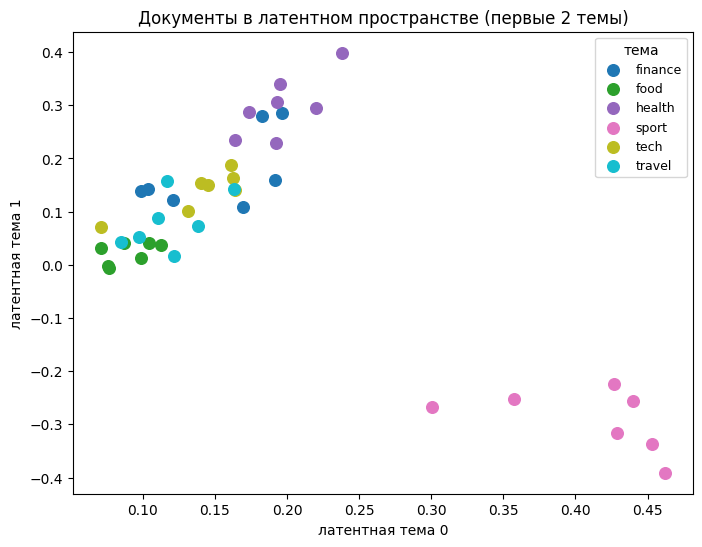

Проекция сохранена: /data/Projects/NLP/lab_2/data/lsa_2d.png


In [12]:
import os, tempfile
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "mplconfig"))
%matplotlib inline

try:
    import matplotlib.pyplot as plt

    doc_topics = [Path(p).stem.rsplit("_", 1)[0] for p in paths]
    labels = sorted(set(doc_topics))
    colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

    plt.figure(figsize=(8, 6))
    for li, lab in enumerate(labels):
        xs = [lsa.doc_vectors_[i, 0] for i, t in enumerate(doc_topics) if t == lab]
        ys = [lsa.doc_vectors_[i, 1] for i, t in enumerate(doc_topics) if t == lab]
        plt.scatter(xs, ys, label=lab, color=colors[li], s=70)
    plt.legend(title="тема", fontsize=9)
    plt.xlabel("латентная тема 0")
    plt.ylabel("латентная тема 1")
    plt.title("Документы в латентном пространстве (первые 2 темы)")
    out_png = _LAB2 / "data" / "lsa_2d.png"
    plt.savefig(str(out_png), dpi=120, bbox_inches="tight")
    plt.show()
    print("Проекция сохранена:", out_png)
except Exception as exc:
    print("Визуализация недоступна:", repr(exc))

## 12. Пользовательские данные

Анализатор переобучается на произвольном корпусе: достаточно положить текстовые
файлы (по документу на файл) в каталог и вызвать `fit`. Ниже — «пользовательский»
корпус `data/custom_corpus/` из 20 документов по 4 темам (музыка, автомобили,
образование, мода), отличным от демо-корпуса.

In [13]:
custom_dir = _LAB2 / "data" / "custom_corpus"
custom_paths = sorted(glob.glob(str(custom_dir / "*.txt")))
custom_texts = load_text_files(custom_paths)
print("Пользовательский корпус:", len(custom_texts), "документов")

custom_model_dir = str(_LAB2 / "src" / "models" / "lsa_custom")
custom_analyzer = SemanticAnalyzer(custom_model_dir)
np.random.seed(42)
cstats = custom_analyzer.fit(custom_texts, k=8, sources=[Path(p).name for p in custom_paths])
print("Обучено: n_docs={}, n_features={}, k={}".format(
    cstats["n_docs"], cstats["n_features"], cstats["k"]))
print("Темы:")
for i, topic in enumerate(custom_analyzer.topics(6)):
    print(f"  Тема {i}: {', '.join(topic)}")
print()
for q in ["Новый альбом и живой концерт группы", "Двигатель и коробка передач автомобиля"]:
    print("Запрос:", q)
    for m in custom_analyzer.query(q, top_n=3):
        print(f"  [{m.score:+.3f}] {m.source}: {m.text[:80]}")
    print()

Пользовательский корпус: 20 документов
Обучено: n_docs=20, n_features=327, k=8
Темы:
  Тема 0: новый, одежда, дизайнер, показ, коллекция, получиться
  Тема 1: одежда, музыкант, дизайнер, мелодия, коллекция, платье
  Тема 2: водитель, машина, двигатель, разгон, расход, топливо
  Тема 3: лекция, студент, учиться, преподаватель, исследование, научный
  Тема 4: композитор, оркестр, симфония, получиться, новый, долго
  Тема 5: исследование, научный, работа, домашний, учитель, объяснить
  Тема 6: показ, правило, исследование, научный, неделя, объяснить
  Тема 7: работа, часть, учитель, готовиться, экзамен, следить

Запрос: Новый альбом и живой концерт группы
  [+0.986] music_03.txt: Рок-группа записала альбом в старой студии с аналоговым пультом. Звук получился 
  [+0.929] music_02.txt: Гитарист выучил новый аккорд и сразу попробовал сыграть любимую мелодию. На урок
  [+0.740] music_04.txt: Академический хор готовится к концерту в большом зале. Репетиции идут каждый ден

Запрос: Двигатель и 

## 13. Масштабный пример на RuReviews (данные `lab_1`)

Тот же конвейер применяется к 2000 отзывам RuReviews (без меток тональности —
LSA не требует разметки). Темами становятся аспекты отзывов: доставка, размер,
качество, ткань и т.п.

In [14]:
rr_model_dir = str(_LAB2 / "src" / "models" / "lsa_rureviews")
rr_analyzer = SemanticAnalyzer(rr_model_dir)
np.random.seed(42)
t0 = time.time()
rr_stats = rr_analyzer.fit(reviews, k=40, min_df=5)
print("RuReviews: n_docs={}, n_features={}, k={}".format(
    rr_stats["n_docs"], rr_stats["n_features"], rr_stats["k"]))
print("Разреженность={:.3f}, время SVD={:.1f} c".format(rr_stats["sparsity"], rr_stats["seconds"]))
print("Топ-термины первых тем:")
for i, topic in enumerate(rr_analyzer.topics(8)[:5]):
    print(f"  Тема {i}: {', '.join(topic)}")
print()
q = "Куртка оказалась мала, пришлось возвращать, но доставка быстрая"
print("Запрос:", q)
for m in rr_analyzer.query(q, top_n=3):
    print(f"  [{m.score:+.3f}] {m.text[:100]}")

RuReviews: n_docs=2000, n_features=814, k=40
Разреженность=0.987, время SVD=0.1 c
Топ-термины первых тем:
  Тема 0: прийти, товар, деньга, вернуть, продавец, спор, заказ, открыть
  Тема 1: размер, плохой, качество, прийти, соответствовать, продавец, вернуть, маленький
  Тема 2: прийти, заказ, получить, товар, спор, продавец, деньга, размер
  Тема 3: прийти, заказ, плохой, товар, качество, деньга, размер, вернуть
  Тема 4: размер, плохой, качество, заказ, прийти, вернуть, соответствовать, деньга

Запрос: Куртка оказалась мала, пришлось возвращать, но доставка быстрая
  [+0.734] Очень маленький размер. Швы не ровные. Доставка быстрая
  [+0.616] Я не знаю,какую фигуру нужно иметь,чтобы данное чудо дизайна подошло.До этого Заказала хл мал.Заказа
  [+0.611] Продавец не может обеспечить нормальную доставку. Я очень надеюсь что мне не придется больше иметь с


## 14. Выводы

- Реализован прототип **LSA**: TF-IDF (scipy.sparse) → усечённый SVD → латентное
  пространство документов и терминов.
- **Нормализация переиспользована из `lab_1`** (стемминг, лемматизация,
  синонимия, стоп-слова); стемминг заметно сжимает словарь и сводит словоформы.
- **Семантический поиск** находит тематически близкие документы даже без точных
  совпадений слов (запрос «своими словами»).
- **Близость документов** группирует их по смыслу без разметки.
- Модель работает на **пользовательских данных** (переобучение на произвольном
  корпусе) и масштабируется на отзывы **RuReviews** (данные `lab_1`).
